In [1]:
# Pandas Lesson 1: Pandas DataFrame
# Pandas introduction
# Pandas Data Structure
# DataFrame introduction
# DataFrame from csv & other format
# DataFrame table using Statistic methods
# List Comprehension & dictionary lookup
# Filter DataFrame
# Sort DataFrame
# Map vs. Apply
# Bin
# Combine
# Concat
# Groupby

In [2]:
import numpy as np
import pandas as pd

In [3]:
#1. Pandas 基础知识
#两个list相加会是什么结果？
list1 = [1,2,3]
list2 = [4,5,6]
print(list1+list2)

[1, 2, 3, 4, 5, 6]


In [4]:
#两个array相加呢？
ary1 = np.array([1,2,3])
ary2 = np.array([4,5,6])
print(ary1+ary2)

[5 7 9]


In [5]:
#array和list的区别
ary3 = ([[1,2,3],
        [4,5,6],
        [7,8,9]])
print(ary3)
print(type(ary3))

[[1, 2, 3], [4, 5, 6], [7, 8, 9]]
<class 'list'>


In [6]:
ary3 = np.array([[1,2,3],
        [4,5,6],
        [7,8,9]])
print(ary3)
print(type(ary3))

[[1 2 3]
 [4 5 6]
 [7 8 9]]
<class 'numpy.ndarray'>


In [7]:
#使用dataframe建表
df = pd.DataFrame(data=ary3, columns=['Name','Age','Income'])
print(df)

   Name  Age  Income
0     1    2       3
1     4    5       6
2     7    8       9


In [8]:
#Dictionary转化成dataframe：
dicta = {'name':"Anna", 'age':18, 'income':1}
dictb = {'name':"Ann", 'age':18, 'income':2}
df = pd.DataFrame([dicta,dictb])
df

,name,age,income
0,Anna,18,1
1,Ann,18,2


In [9]:
len(df.index)

2

In [11]:
#3. DataFrame from csv & other format
#读csv
df = pd.read_csv(r'datasets/3.4 Wty_Claims_data_new.csv') #请添加自己的location

In [12]:
#3.1 读完csv之后的基础操作
#前20行
df[:20]
df.columns
#前面5行5列
df.iloc[:5,:5]
#最后5行
df[-5:]

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
24374,131404,NaN,11/12/2015,92767.0,WA,6.0,FM13A64T,NaN,22437002,"MOUNTING BASE, LHS. TCM BAR",...,0.0,340.40,340.40,NaN,NaN,42418,9,42401,FM13,2016
24375,131506,NaN,8/02/2016,92767.0,WA,1.0,FM13A64T,NaN,22437003,"MOUNTING BASE, RHS. TCM BAR",...,196.0,510.80,510.80,NaN,NaN,42425,9,42401,FM13,2016
24376,131405,NaN,8/01/2016,92767.0,WA,2.0,FM13A64T,NaN,22437002,"MOUNTING BASE, LHS. TCM BAR",...,0.0,341.90,341.90,NaN,NaN,42418,9,42401,FM13,2016
24377,131278,NaN,24/12/2015,92767.0,WA,7.0,FM13A64T,NaN,22437002,"MOUNTING BASE, LHS. TCM BAR",...,0.0,340.40,340.40,NaN,NaN,42411,9,42401,FM13,2016
24378,131631,NaN,28/01/2016,92767.0,WA,1.0,FM13A64T,NaN,22219284,"SENSOR, NOX 900MM, POST-SCR",...,312.0,1193.85,1193.85,NaN,NaN,42425,9,42401,FM13,2016


In [13]:
#一共多少行
len(df.index)

24379

In [14]:
#3.2 筛选表中的信息，读出payment相关的信息以及他的Repairing Dealer和Claim Registration Date
#分3步走

In [15]:
#step1：读出表中column name里有payment这个词的column
columns_payment = [n for n in df.columns if 'Payment' in n]
columns_payment

['Total Labor Payment Local',
 'Total Material Payment Local',
 'Total Other Payment Local',
 'Total Payment Local',
 'Total_Payment']

In [16]:
#step2: 读出表中有这两列'Repairing Dealer', 'Claim Registration Date'的column
columns_list = ['Repairing Dealer', 'Claim Registration Date']

In [17]:
#step3: 合并
columns_list = columns_list + columns_payment
columns_list
#显示7列数据
df[columns_list]

,Repairing Dealer,Claim Registration Date,Total Labor Payment Local,Total Material Payment Local,Total Other Payment Local,Total Payment Local,Total_Payment
0,490233.0,NaN,1430.28,5939.73,0.0,7370.01,7370.01
1,93385.0,NaN,48.60,124.62,0.0,173.22,173.22
2,79129.0,NaN,233.91,115.71,160.0,509.62,509.62
3,691188.0,NaN,1378.60,485.60,0.0,1864.20,1864.20
4,92767.0,NaN,207.40,2038.92,0.0,2246.32,2246.32
...,...,...,...,...,...,...,...
24374,92767.0,NaN,183.00,157.40,0.0,340.40,340.40
24375,92767.0,NaN,0.00,314.80,196.0,510.80,510.80
24376,92767.0,NaN,184.50,157.40,0.0,341.90,341.90
24377,92767.0,NaN,183.00,157.40,0.0,340.40,340.40


In [18]:
#熟练之后，与上面分步骤相同
df.columns
columns_payment = ['Repairing Dealer', 'Claim Registration Date'] + [n for n in df.columns if 'Payment' in n]
df[columns_payment]

,Repairing Dealer,Claim Registration Date,Total Labor Payment Local,Total Material Payment Local,Total Other Payment Local,Total Payment Local,Total_Payment
0,490233.0,NaN,1430.28,5939.73,0.0,7370.01,7370.01
1,93385.0,NaN,48.60,124.62,0.0,173.22,173.22
2,79129.0,NaN,233.91,115.71,160.0,509.62,509.62
3,691188.0,NaN,1378.60,485.60,0.0,1864.20,1864.20
4,92767.0,NaN,207.40,2038.92,0.0,2246.32,2246.32
...,...,...,...,...,...,...,...
24374,92767.0,NaN,183.00,157.40,0.0,340.40,340.40
24375,92767.0,NaN,0.00,314.80,196.0,510.80,510.80
24376,92767.0,NaN,184.50,157.40,0.0,341.90,341.90
24377,92767.0,NaN,183.00,157.40,0.0,340.40,340.40


In [19]:
#3.3 写csv

In [23]:
#将column name里有payment这个词的column + ‘Repairing Dealer', 'Claim Registration Date'的column写到csv里
columns_payment = ['Repairing Dealer', 'Claim Registration Date'] + [n for n in df.columns if 'Payment' in n]
df_new = df[columns_payment]
df_new.to_csv(r'output/Wty_Claims_payment_only.csv', index = False)#注意改路径

In [24]:
#3.4 tolist使用方式

In [25]:
#摘出state这一列
df['State'].tolist()
#df每个column就是一个list

['QLD',
 'NSW',
 'VIC',
 'SA',
 'WA',
 'WA',
 'NSW',
 'QLD',
 'NSW',
 'NSW',
 'VIC',
 'SA',
 'WA',
 'NSW',
 'NSW',
 'QLD',
 'WA',
 'QLD',
 'SA',
 'NSW',
 'WA',
 'QLD',
 'QLD',
 'VIC',
 'VIC',
 'SA',
 'WA',
 'WA',
 'VIC',
 'WA',
 'WA',
 'TA',
 'WA',
 'QLD',
 'WA',
 'WA',
 'QLD',
 'WA',
 'QLD',
 'WA',
 'WA',
 'WA',
 'WA',
 'NSW',
 'NSW',
 'SA',
 'WA',
 'VIC',
 'VIC',
 'VIC',
 'QLD',
 'WA',
 'WA',
 'SA',
 'SA',
 'SA',
 'SA',
 'WA',
 'WA',
 'WA',
 'WA',
 'WA',
 'VIC',
 'VIC',
 'VIC',
 'SA',
 'SA',
 'NSW',
 'NSW',
 'NSW',
 'WA',
 'VIC',
 'VIC',
 'VIC',
 'NSW',
 'NSW',
 'NSW',
 'NSW',
 'NSW',
 'NSW',
 'SA',
 'SA',
 'SA',
 'SA',
 'SA',
 'NSW',
 'NSW',
 'NSW',
 'WA',
 'WA',
 'NSW',
 'SA',
 'SA',
 'VIC',
 'QLD',
 'QLD',
 'QLD',
 'SA',
 'SA',
 'SA',
 'QLD',
 'SA',
 'SA',
 'VIC',
 'VIC',
 'QLD',
 'WA',
 'WA',
 'NSW',
 'NSW',
 'NSW',
 'NSW',
 'VIC',
 'VIC',
 'WA',
 'WA',
 'WA',
 'WA',
 'WA',
 'WA',
 'NSW',
 'VIC',
 'VIC',
 'VIC',
 'QLD',
 'WA',
 'QLD',
 'NSW',
 'QLD',
 'QLD',
 'SA',
 'WA',
 'NSW',

In [26]:
df['State'].unique().tolist()

['QLD', 'NSW', 'VIC', 'SA', 'WA', 'TA', nan]

In [27]:
#用numpy返回array
np.unique(df['State'].tolist())

array(['NSW', 'QLD', 'SA', 'TA', 'VIC', 'WA', 'nan'], dtype='<U32')

In [28]:
#变set
set((df['State'].tolist()))

{'NSW', 'QLD', 'SA', 'TA', 'VIC', 'WA', nan}

In [29]:
#变list
list(set((df['State'].tolist())))

[nan, 'NSW', 'TA', 'VIC', 'QLD', 'SA', 'WA']

In [30]:
#3.5 remove duplicate

In [31]:
# 在vehicle Marketing Type','State' 两列中去掉重复
df_VS = df[['Vehicle Marketing Type','State']].drop_duplicates()
df_VS

,Vehicle Marketing Type,State
0,FH13 64T,QLD
1,FH13 64T,NSW
2,FH13 64T,VIC
3,FH13 64T,SA
4,FH13 64T,WA
...,...,...
24110,FH13A84T,SA
24213,FH16A84T,QLD
24224,FH16A84T,WA
24263,FM11A64T,VIC


In [32]:
#3.6 index

In [33]:
#改index
df_VS = df_VS.reset_index()
df_VS

,index,Vehicle Marketing Type,State
0,0,FH13 64T,QLD
1,1,FH13 64T,NSW
2,2,FH13 64T,VIC
3,3,FH13 64T,SA
4,4,FH13 64T,WA
...,...,...,...
161,24110,FH13A84T,SA
162,24213,FH16A84T,QLD
163,24224,FH16A84T,WA
164,24263,FM11A64T,VIC


In [34]:
df_VSP = df_VS.reindex(columns=['Vehicle Marketing Type','State','PlaceHolder'])
df_VSP

,Vehicle Marketing Type,State,PlaceHolder
0,FH13 64T,QLD,NaN
1,FH13 64T,NSW,NaN
2,FH13 64T,VIC,NaN
3,FH13 64T,SA,NaN
4,FH13 64T,WA,NaN
...,...,...,...
161,FH13A84T,SA,NaN
162,FH16A84T,QLD,NaN
163,FH16A84T,WA,NaN
164,FM11A64T,VIC,NaN


In [35]:
#3.7 超过5000的claim需要check
columns_payment = ['Repairing Dealer','Claim Registration Date'] + [n for n in df.columns if 'Payment' in n]
df_new = df[columns_payment]
df_new['Check_status'] = ['check' if n>5000 else 'no check' for n in df['Total_Payment']]
df_new

/var/folders/bv/dtsl2dms55b8p7r8cf91tk_r0000gn/T/ipykernel_80515/1333024469.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Check_status'] = ['check' if n>5000 else 'no check' for n in df['Total_Payment']]


,Repairing Dealer,Claim Registration Date,Total Labor Payment Local,Total Material Payment Local,Total Other Payment Local,Total Payment Local,Total_Payment,Check_status
0,490233.0,NaN,1430.28,5939.73,0.0,7370.01,7370.01,check
1,93385.0,NaN,48.60,124.62,0.0,173.22,173.22,no check
2,79129.0,NaN,233.91,115.71,160.0,509.62,509.62,no check
3,691188.0,NaN,1378.60,485.60,0.0,1864.20,1864.20,no check
4,92767.0,NaN,207.40,2038.92,0.0,2246.32,2246.32,no check
...,...,...,...,...,...,...,...,...
24374,92767.0,NaN,183.00,157.40,0.0,340.40,340.40,no check
24375,92767.0,NaN,0.00,314.80,196.0,510.80,510.80,no check
24376,92767.0,NaN,184.50,157.40,0.0,341.90,341.90,no check
24377,92767.0,NaN,183.00,157.40,0.0,340.40,340.40,no check


In [36]:
#将上面改写成容易阅读的模式
check_status = list()
for n in df['Total_Payment']:
    if n>5000:
        check_status.append('check')
    else:
        check_status.append('no check')

df_new['check_status'] = check_status
df_new

/var/folders/bv/dtsl2dms55b8p7r8cf91tk_r0000gn/T/ipykernel_80515/3095547809.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['check_status'] = check_status


,Repairing Dealer,Claim Registration Date,Total Labor Payment Local,Total Material Payment Local,Total Other Payment Local,Total Payment Local,Total_Payment,Check_status,check_status
0,490233.0,NaN,1430.28,5939.73,0.0,7370.01,7370.01,check,check
1,93385.0,NaN,48.60,124.62,0.0,173.22,173.22,no check,no check
2,79129.0,NaN,233.91,115.71,160.0,509.62,509.62,no check,no check
3,691188.0,NaN,1378.60,485.60,0.0,1864.20,1864.20,no check,no check
4,92767.0,NaN,207.40,2038.92,0.0,2246.32,2246.32,no check,no check
...,...,...,...,...,...,...,...,...,...
24374,92767.0,NaN,183.00,157.40,0.0,340.40,340.40,no check,no check
24375,92767.0,NaN,0.00,314.80,196.0,510.80,510.80,no check,no check
24376,92767.0,NaN,184.50,157.40,0.0,341.90,341.90,no check,no check
24377,92767.0,NaN,183.00,157.40,0.0,340.40,340.40,no check,no check


In [37]:
#4.DataFrame table using Statistic methods

In [39]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 6.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.5/251.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 8.7 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 8.1 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 5.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


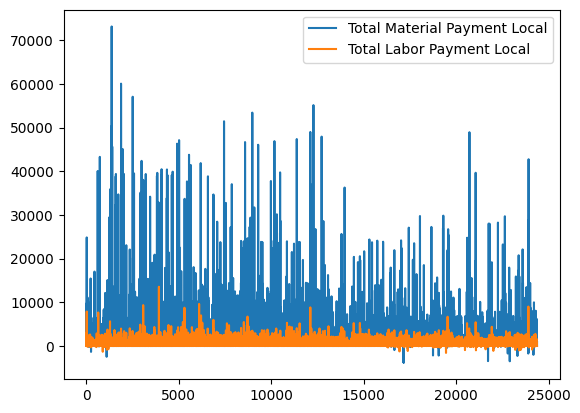

In [40]:
import matplotlib.pyplot as plt
df_Payment = df[['Total Material Payment Local','Total Labor Payment Local']].plot()

In [41]:
#5.Filter

In [42]:
#只分析state是QLD的数据，以下四种写法的区别
df_QLD = df[df['State'] =='QLD']
df_QLD = df_QLD.reset_index()
df_QLD

,index,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,0,7982280,NaN,10/08/2015,490233.0,QLD,1.0,FH13 64T,NaN,85003217,...,0.0,7370.01,7370.01,NaN,NaN,42250,9,42248,FH13,2015
1,7,7983563,NaN,27/08/2015,488428.0,QLD,1.0,FH13 64T,NaN,20981227,...,0.0,1736.57,1736.57,#DIV/0!,NaN,42250,9,42248,FH13,2015
2,15,7983366,NaN,17/08/2015,93351.0,QLD,1.0,FH13 64T,NaN,21479276,...,0.0,503.11,503.11,NaN,NaN,42250,9,42248,FH13,2015
3,17,7983564,NaN,1/09/2015,488428.0,QLD,1.0,FH13 64T,NaN,21422765,...,0.0,324.84,324.84,NaN,NaN,42250,9,42248,FH13,2015
4,21,7983452,NaN,29/08/2015,488428.0,QLD,4.0,FH13A64T,NaN,21634024,...,0.0,286.77,286.77,NaN,NaN,42250,9,42248,FH13,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3776,24348,7990313,NaN,14/12/2015,93351.0,QLD,1.0,FM13 64T,NaN,20910779,...,140.0,564.88,564.88,NaN,NaN,42411,9,42401,FM13,2016
3777,24349,7991729,NaN,22/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,21772668,...,0.0,1749.80,1749.80,NaN,NaN,42411,9,42401,FM13,2016
3778,24352,7991560,NaN,28/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,1674083,...,0.0,60.49,60.49,NaN,NaN,42411,9,42401,FM13,2016
3779,24368,7991228,NaN,6/01/2016,93351.0,QLD,1.0,FM13A64T,NaN,21574975,...,0.0,1366.90,1366.90,NaN,NaN,42418,9,42401,FM13,2016


In [43]:
df_QLD = df[df['State'] =='QLD']
df_QLD = df_QLD.reset_index(drop=True)
df_QLD

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,7982280,NaN,10/08/2015,490233.0,QLD,1.0,FH13 64T,NaN,85003217,"CYLINDER HEAD, EXCH, SPARE PART",...,0.0,7370.01,7370.01,NaN,NaN,42250,9,42248,FH13,2015
1,7983563,NaN,27/08/2015,488428.0,QLD,1.0,FH13 64T,NaN,20981227,"FAN, ER175 + TR750KSR",...,0.0,1736.57,1736.57,#DIV/0!,NaN,42250,9,42248,FH13,2015
2,7983366,NaN,17/08/2015,93351.0,QLD,1.0,FH13 64T,NaN,21479276,"BELT TENSIONER, 10K, D=74, L=90, T=37NM",...,0.0,503.11,503.11,NaN,NaN,42250,9,42248,FH13,2015
3,7983564,NaN,1/09/2015,488428.0,QLD,1.0,FH13 64T,NaN,21422765,"BELT TENSIONER, 10K- D=74- L=95- T=43N.M",...,0.0,324.84,324.84,NaN,NaN,42250,9,42248,FH13,2015
4,7983452,NaN,29/08/2015,488428.0,QLD,4.0,FH13A64T,NaN,21634024,"PRESSURE SENSOR, EXHAUST PRESSURE",...,0.0,286.77,286.77,NaN,NaN,42250,9,42248,FH13,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3776,7990313,NaN,14/12/2015,93351.0,QLD,1.0,FM13 64T,NaN,20910779,"EXHAUST MANIFOLD, FRONT AND REAR",...,140.0,564.88,564.88,NaN,NaN,42411,9,42401,FM13,2016
3777,7991729,NaN,22/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,21772668,"FAN, 842B + XD11-680",...,0.0,1749.80,1749.80,NaN,NaN,42411,9,42401,FM13,2016
3778,7991560,NaN,28/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,1674083,"PRESSURE CAP, (75KPA)",...,0.0,60.49,60.49,NaN,NaN,42411,9,42401,FM13,2016
3779,7991228,NaN,6/01/2016,93351.0,QLD,1.0,FM13A64T,NaN,21574975,"PUMP UNIT, UREA DOSING SYSTEM",...,0.0,1366.90,1366.90,NaN,NaN,42418,9,42401,FM13,2016


In [44]:
df_QLD = df[df['State'] =='QLD']
df_QLD.reset_index(drop=True)
df_QLD

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,7982280,NaN,10/08/2015,490233.0,QLD,1.0,FH13 64T,NaN,85003217,"CYLINDER HEAD, EXCH, SPARE PART",...,0.0,7370.01,7370.01,NaN,NaN,42250,9,42248,FH13,2015
7,7983563,NaN,27/08/2015,488428.0,QLD,1.0,FH13 64T,NaN,20981227,"FAN, ER175 + TR750KSR",...,0.0,1736.57,1736.57,#DIV/0!,NaN,42250,9,42248,FH13,2015
15,7983366,NaN,17/08/2015,93351.0,QLD,1.0,FH13 64T,NaN,21479276,"BELT TENSIONER, 10K, D=74, L=90, T=37NM",...,0.0,503.11,503.11,NaN,NaN,42250,9,42248,FH13,2015
17,7983564,NaN,1/09/2015,488428.0,QLD,1.0,FH13 64T,NaN,21422765,"BELT TENSIONER, 10K- D=74- L=95- T=43N.M",...,0.0,324.84,324.84,NaN,NaN,42250,9,42248,FH13,2015
21,7983452,NaN,29/08/2015,488428.0,QLD,4.0,FH13A64T,NaN,21634024,"PRESSURE SENSOR, EXHAUST PRESSURE",...,0.0,286.77,286.77,NaN,NaN,42250,9,42248,FH13,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24348,7990313,NaN,14/12/2015,93351.0,QLD,1.0,FM13 64T,NaN,20910779,"EXHAUST MANIFOLD, FRONT AND REAR",...,140.0,564.88,564.88,NaN,NaN,42411,9,42401,FM13,2016
24349,7991729,NaN,22/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,21772668,"FAN, 842B + XD11-680",...,0.0,1749.80,1749.80,NaN,NaN,42411,9,42401,FM13,2016
24352,7991560,NaN,28/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,1674083,"PRESSURE CAP, (75KPA)",...,0.0,60.49,60.49,NaN,NaN,42411,9,42401,FM13,2016
24368,7991228,NaN,6/01/2016,93351.0,QLD,1.0,FM13A64T,NaN,21574975,"PUMP UNIT, UREA DOSING SYSTEM",...,0.0,1366.90,1366.90,NaN,NaN,42418,9,42401,FM13,2016


In [45]:
df_QLD = df[df['State'] =='QLD']
df_QLD.reset_index(drop=True, inplace=True)
df_QLD

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,7982280,NaN,10/08/2015,490233.0,QLD,1.0,FH13 64T,NaN,85003217,"CYLINDER HEAD, EXCH, SPARE PART",...,0.0,7370.01,7370.01,NaN,NaN,42250,9,42248,FH13,2015
1,7983563,NaN,27/08/2015,488428.0,QLD,1.0,FH13 64T,NaN,20981227,"FAN, ER175 + TR750KSR",...,0.0,1736.57,1736.57,#DIV/0!,NaN,42250,9,42248,FH13,2015
2,7983366,NaN,17/08/2015,93351.0,QLD,1.0,FH13 64T,NaN,21479276,"BELT TENSIONER, 10K, D=74, L=90, T=37NM",...,0.0,503.11,503.11,NaN,NaN,42250,9,42248,FH13,2015
3,7983564,NaN,1/09/2015,488428.0,QLD,1.0,FH13 64T,NaN,21422765,"BELT TENSIONER, 10K- D=74- L=95- T=43N.M",...,0.0,324.84,324.84,NaN,NaN,42250,9,42248,FH13,2015
4,7983452,NaN,29/08/2015,488428.0,QLD,4.0,FH13A64T,NaN,21634024,"PRESSURE SENSOR, EXHAUST PRESSURE",...,0.0,286.77,286.77,NaN,NaN,42250,9,42248,FH13,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3776,7990313,NaN,14/12/2015,93351.0,QLD,1.0,FM13 64T,NaN,20910779,"EXHAUST MANIFOLD, FRONT AND REAR",...,140.0,564.88,564.88,NaN,NaN,42411,9,42401,FM13,2016
3777,7991729,NaN,22/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,21772668,"FAN, 842B + XD11-680",...,0.0,1749.80,1749.80,NaN,NaN,42411,9,42401,FM13,2016
3778,7991560,NaN,28/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,1674083,"PRESSURE CAP, (75KPA)",...,0.0,60.49,60.49,NaN,NaN,42411,9,42401,FM13,2016
3779,7991228,NaN,6/01/2016,93351.0,QLD,1.0,FM13A64T,NaN,21574975,"PUMP UNIT, UREA DOSING SYSTEM",...,0.0,1366.90,1366.90,NaN,NaN,42418,9,42401,FM13,2016


In [46]:
#state是QLD，NSW
df_ = df[df['State'].isin(['QLD','NSW'])]
df_.reset_index(drop=True,inplace=True)
df_

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,7982280,NaN,10/08/2015,490233.0,QLD,1.0,FH13 64T,NaN,85003217,"CYLINDER HEAD, EXCH, SPARE PART",...,0.00,7370.01,7370.01,NaN,NaN,42250,9,42248,FH13,2015
1,133058,NaN,27/08/2015,93385.0,NSW,1.0,FH13 64T,NaN,20538793,"SEALING STRIP, VALVE COVER",...,0.00,173.22,173.22,NaN,NaN,42250,9,42248,FH13,2015
2,7983254,NaN,25/08/2015,630208.0,NSW,1.0,FH13 64T,NaN,21302639,"PRESSURE SENSOR, FUEL/OIL",...,0.00,314.84,314.84,#DIV/0!,NaN,42250,9,42248,FH13,2015
3,7983563,NaN,27/08/2015,488428.0,QLD,1.0,FH13 64T,NaN,20981227,"FAN, ER175 + TR750KSR",...,0.00,1736.57,1736.57,#DIV/0!,NaN,42250,9,42248,FH13,2015
4,7983393,NaN,28/08/2015,766085.0,NSW,4.0,FH13 64T,NaN,85139619,PRESSURE SENSOR,...,0.00,320.79,320.79,#DIV/0!,NaN,42250,9,42248,FH13,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6714,7991099,NaN,28/01/2016,766085.0,NSW,1.0,FM13 64T,NaN,21772668,"FAN, 842B + XD11-680",...,0.00,1562.34,1562.34,NaN,NaN,42404,9,42401,FM13,2016
6715,7991560,NaN,28/01/2016,93351.0,QLD,1.0,FM13 64T,NaN,1674083,"PRESSURE CAP, (75KPA)",...,0.00,60.49,60.49,NaN,NaN,42411,9,42401,FM13,2016
6716,7991835,NaN,19/01/2016,511728.0,NSW,1.0,FM13 84R,NaN,1524988,"ROLLER BEARING, 32010X, OUTPUT SHAFT",...,1246.97,2359.21,2359.21,NaN,NaN,42418,9,42401,FM13,2016
6717,7991228,NaN,6/01/2016,93351.0,QLD,1.0,FM13A64T,NaN,21574975,"PUMP UNIT, UREA DOSING SYSTEM",...,0.00,1366.90,1366.90,NaN,NaN,42418,9,42401,FM13,2016


In [47]:
#state除了QLD，NSW
df_ = df[~df['State'].isin(['QLD','NSW'])]
df_.reset_index(drop=True,inplace=True)
df_

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,7982526,NaN,12/08/2015,79129.0,VIC,2.0,FH13 64T,NaN,20910962,"EXHAUST MANIFOLD, FRONT AND REAR",...,160.0,509.62,509.62,#DIV/0!,NaN,42250,9,42248,FH13,2015
1,1202209,NaN,28/08/2015,691188.0,SA,1.0,FH13 64T,NaN,21351717,"INJECTOR SLEEVE, SPARE PART KIT",...,0.0,1864.20,1864.20,3.185125,NaN,42250,9,42248,FH13,2015
2,130161,NaN,28/08/2015,92767.0,WA,2.0,FH13 64T,NaN,21368390,"OIL PAN, PLASTIC",...,0.0,2246.32,2246.32,#DIV/0!,NaN,42250,9,42248,FH13,2015
3,130161,NaN,28/08/2015,92767.0,WA,3.0,FH13 64T,NaN,21042447,"OIL LEVEL SENSOR, OIL LEVEL & TEMP",...,0.0,109.80,109.80,#DIV/0!,NaN,42250,9,42248,FH13,2015
4,2003894,NaN,25/08/2015,880625.0,VIC,3.0,FH13 64T,NaN,21818731,"EXHAUST BRAKE, CLOSED LOOP",...,0.0,1723.74,1723.74,#DIV/0!,NaN,42250,9,42248,FH13,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17655,131404,NaN,11/12/2015,92767.0,WA,6.0,FM13A64T,NaN,22437002,"MOUNTING BASE, LHS. TCM BAR",...,0.0,340.40,340.40,NaN,NaN,42418,9,42401,FM13,2016
17656,131506,NaN,8/02/2016,92767.0,WA,1.0,FM13A64T,NaN,22437003,"MOUNTING BASE, RHS. TCM BAR",...,196.0,510.80,510.80,NaN,NaN,42425,9,42401,FM13,2016
17657,131405,NaN,8/01/2016,92767.0,WA,2.0,FM13A64T,NaN,22437002,"MOUNTING BASE, LHS. TCM BAR",...,0.0,341.90,341.90,NaN,NaN,42418,9,42401,FM13,2016
17658,131278,NaN,24/12/2015,92767.0,WA,7.0,FM13A64T,NaN,22437002,"MOUNTING BASE, LHS. TCM BAR",...,0.0,340.40,340.40,NaN,NaN,42411,9,42401,FM13,2016


In [48]:
#state除了QLD，NSW +Causal Part Name有oil
df_ = df[~df['State'].isin(['QLD','NSW']) & (df['Causal Part Name'].str.contains('OIL'))]
df_.reset_index(drop=True,inplace=True)
df_

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,130161,NaN,28/08/2015,92767.0,WA,2.0,FH13 64T,NaN,21368390,"OIL PAN, PLASTIC",...,0.00,2246.32,2246.32,#DIV/0!,NaN,42250,9,42248,FH13,2015
1,130161,NaN,28/08/2015,92767.0,WA,3.0,FH13 64T,NaN,21042447,"OIL LEVEL SENSOR, OIL LEVEL & TEMP",...,0.00,109.80,109.80,#DIV/0!,NaN,42250,9,42248,FH13,2015
2,4803155,NaN,28/08/2015,396485.0,VIC,5.0,FH13A64T,NaN,20541940,"SEALING STRIP, OIL PAN PLASTIC",...,0.00,166.67,166.67,NaN,NaN,42250,9,42248,FH13,2015
3,4803155,NaN,28/08/2015,396485.0,VIC,4.0,FH13A64T,NaN,22095518,"OIL FILTER HOUSING, THERMAL MANAGEMENT",...,0.00,1479.13,1479.13,NaN,NaN,42250,9,42248,FH13,2015
4,7982998,NaN,22/07/2015,70287.0,WA,1.0,FES7 62R,NaN,21333678,OIL PAN,...,15.62,1167.51,1167.51,NaN,NaN,42243,9,42217,FES7,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2878,417328,NaN,9/12/2015,542457.0,WA,2.0,FM13 64T,NaN,20740683,"VALVE COVER, W. OIL TRAP, FM/FH",...,0.00,711.10,711.10,NaN,NaN,42411,9,42401,FM13,2016
2879,1202934,NaN,13/10/2015,691188.0,SA,1.0,FM13 64T,NaN,21634021,"PRESSURE SENSOR, FUEL / OIL PRESSURE",...,0.00,398.44,398.44,NaN,NaN,42404,9,42401,FM13,2016
2880,1203379,NaN,7/02/2016,691188.0,SA,1.0,FM13 64T,NaN,21634021,"PRESSURE SENSOR, FUEL / OIL PRESSURE",...,0.00,399.81,399.81,NaN,NaN,42411,9,42401,FM13,2016
2881,139491,NaN,3/02/2016,600828.0,SA,2.0,FM13 64T,NaN,21818292,"OIL HOSE, GEARBOX",...,0.00,244.72,244.72,NaN,NaN,42425,9,42401,FM13,2016


In [49]:
#state除了QLD，NSW +一个条件是Causal Part Name有oil 再加一个条件是company不为null
df_ = df[~df['State'].isin(['QLD','NSW']) & (df['Causal Part Name'].str.contains('OIL')) & (df['Company'].notnull())]
df_.reset_index(drop=True,inplace=True)
df_

,Refno Claim,Claim Registration Date,Repair Date,Repairing Dealer,State,Job Number,Vehicle Marketing Type,Product Id,Causal Part Number,Causal Part Name,...,Total Other Payment Local,Total Payment Local,Total_Payment,Company,Delivery Importer,Credit Date,Debit Code,Credit Period,Model_,Year
0,130161,NaN,28/08/2015,92767.0,WA,2.0,FH13 64T,NaN,21368390,"OIL PAN, PLASTIC",...,0.0,2246.32,2246.32,#DIV/0!,NaN,42250,9,42248,FH13,2015
1,130161,NaN,28/08/2015,92767.0,WA,3.0,FH13 64T,NaN,21042447,"OIL LEVEL SENSOR, OIL LEVEL & TEMP",...,0.0,109.80,109.80,#DIV/0!,NaN,42250,9,42248,FH13,2015
2,231245,40161.0,17/11/2009,691188.0,SA,1.0,FH16 64T,130622.0,420641,"GASKET, OIL INLET/TURBO",...,0.0,92.01,92.01,VTC,7830.0,40192,9,40179,FH16,2010
3,1123,40171.0,8/12/2009,482666.0,VIC,2.0,FH16 64T,131059.0,20898038,"PRESSURE SENSOR, FUEL/OIL",...,0.0,374.75,374.75,VTC,7830.0,40192,9,40179,FH16,2010
4,12367,40171.0,13/12/2009,601571.0,SA,4.0,FH13 64T,127425.0,21107513,"DIPSTICK, OIL",...,0.0,139.01,139.01,VTC,7830.0,40192,9,40179,FH13,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,7955443,41607.0,8/11/2013,92197.0,SA,2.0,FM13 64T,134292.0,21634021,"PRESSURE SENSOR, FUEL / OIL PRESSURE",...,0.0,-165.55,0.00,VTC,7830.0,41627,9,41609,FM13,2013
1496,7955531,41610.0,25/11/2013,70287.0,WA,2.0,FH16 64T,134869.0,21302639,"PRESSURE SENSOR, FUEL/OIL",...,0.0,426.96,853.92,VTC,7830.0,41627,9,41609,FH16,2013
1497,7955919,41621.0,9/12/2013,92197.0,SA,1.0,FM11 42T,134200.0,21302639,"PRESSURE SENSOR, FUEL/OIL",...,0.0,363.09,363.09,VTC,7830.0,41627,9,41609,FM11,2013
1498,7955999,41624.0,12/12/2013,79129.0,VIC,1.0,FH13 64T,135230.0,21302639,"PRESSURE SENSOR, FUEL/OIL",...,0.0,334.37,334.37,VTC,7830.0,41627,9,41609,FH13,2013
